Task 2: Credit Risk Prediction

Objective: Predict whether a loan applicant is likely to default on a loan using classification techniques.

1. Environment Setup & Data Loading
First, we will import the necessary libraries for data manipulation, visualization, and machine learning. Then, we will load the provided dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv('test-selected-columns.csv')

# Quick preview of the data
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (367, 10)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0


2. Exploratory Data Analysis & Handling Missing Data
Before building a model, we need to understand the missing values in our dataset and fix them appropriately.

2.1 Identifying Missing Values

In [2]:
# Check for missing values per column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
dtype: int64


2.2 Imputing Missing Values
Categorical features (Gender, Married, Dependents, Self_Employed): We will fill missing values using the mode (most frequent value).

Numerical features (LoanAmount, Loan_Amount_Term): We will fill missing values using the median to avoid the influence of potential outliers.

In [3]:
# Impute Categorical Columns with Mode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Impute Numerical Columns with Median
numerical_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Verify that no missing values remain
print("Missing values after imputation:")
print(df.isnull().sum().sum())

Missing values after imputation:
0


3. Data Visualization
Visualizing data helps us spot distributions, skewness, and relationships between features.

3.1 Distribution of Loan Amount and Applicant Income

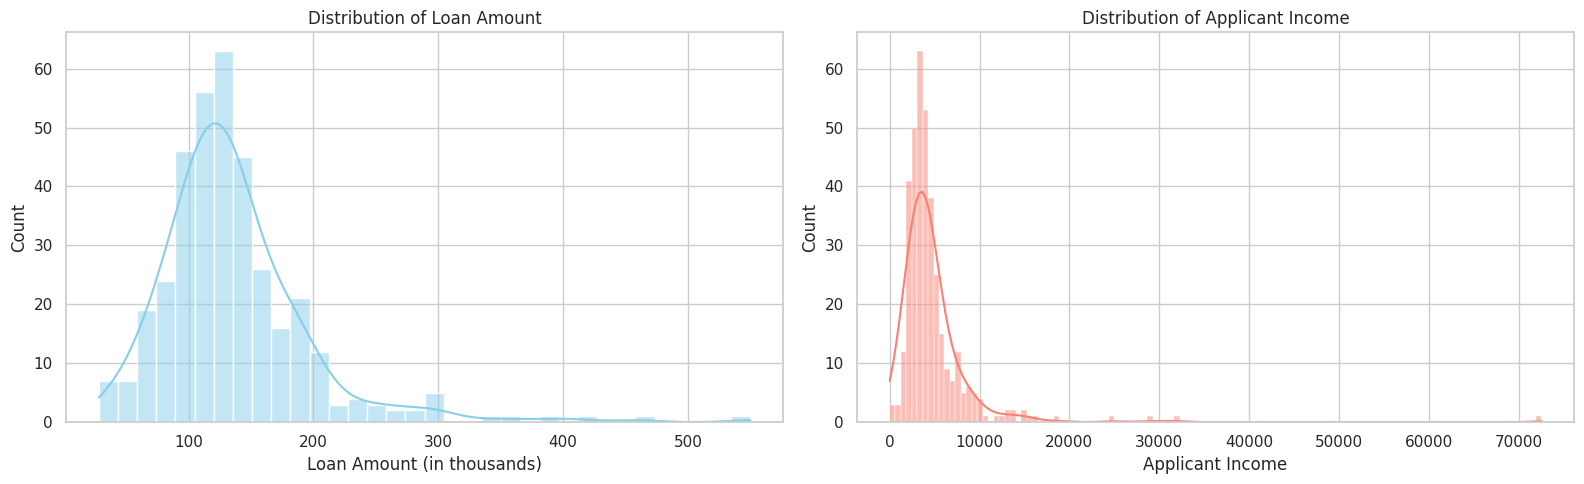

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loan Amount Distribution
sns.histplot(df['LoanAmount'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Loan Amount')
axes[0].set_xlabel('Loan Amount (in thousands)')

# Applicant Income Distribution
sns.histplot(df['ApplicantIncome'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Applicant Income')
axes[1].set_xlabel('Applicant Income')

plt.tight_layout()
plt.show()

3.2 Impact of Education on Loan Amounts

/tmp/ipykernel_1805/1637806060.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education', y='LoanAmount', data=df, palette='Set2')


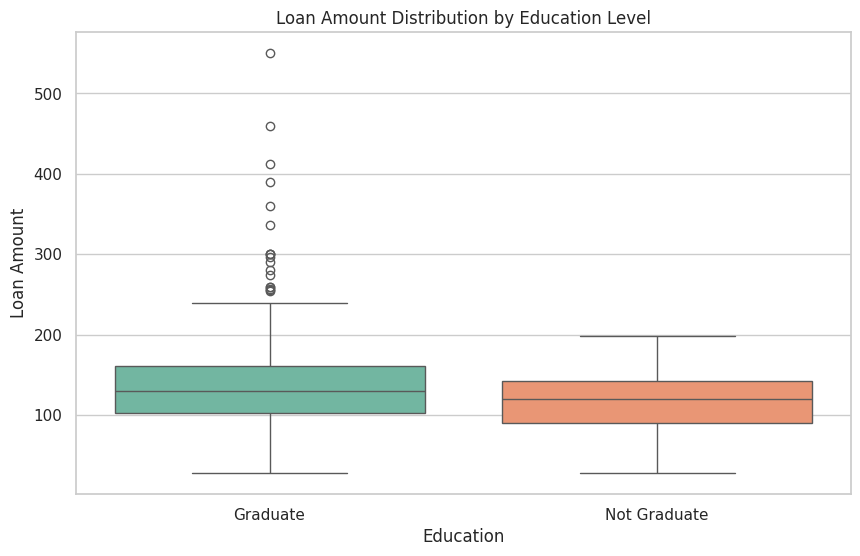

In [5]:
sns.boxplot(x='Education', y='LoanAmount', data=df, palette='Set2')
plt.title('Loan Amount Distribution by Education Level')
plt.xlabel('Education')
plt.ylabel('Loan Amount')
plt.show()

4. Data Preprocessing & Feature Engineering
Machine learning algorithms require numeric inputs, so we must encode our categorical text data.

Note: Since the uploaded test snippet does not contain a historical ground-truth target column (like Loan_Status), we will create a synthetic target variable based on a logical business rule for demonstration purposes (e.g., higher debt-to-income ratio increases risk).

In [6]:
# Creating a dummy 'Loan_Status' target variable for modeling purposes
# (1 = Default/Risk, 0 = Safe)
# A realistic proxy: If LoanAmount is high relative to total income, risk increases.
total_income = df['ApplicantIncome'] + df['CoapplicantIncome']
debt_to_income = df['LoanAmount'] / (total_income + 1)
df['Loan_Status'] = np.where(debt_to_income > debt_to_income.median(), 1, 0)

print("Target variable distribution:")
print(df['Loan_Status'].value_counts(normalize=True))

Target variable distribution:
Loan_Status
0    0.501362
1    0.498638
Name: proportion, dtype: float64


4.1 Categorical Encoding

In [7]:
# Drop Loan_ID as it's just a unique identifier
df_model = df.drop(columns=['Loan_ID'])

# Label Encode categorical features
le = LabelEncoder()
cols_to_encode = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed']

for col in cols_to_encode:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Loan_Status
0,1,1,0,0,0,5720,0,110.0,360.0,0
1,1,1,1,0,0,3076,1500,126.0,360.0,1
2,1,1,2,0,0,5000,1800,208.0,360.0,1
3,1,1,2,0,0,2340,2546,100.0,360.0,0
4,1,0,0,1,0,3276,0,78.0,360.0,0


4.2 Feature Scaling & Splitting

In [8]:
# Separate features and target
X = df_model.drop(columns=['Loan_Status'])
y = df_model['Loan_Status']

# Split into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features for better Logistic Regression performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

5. Model Training & Evaluation
We will train both a Logistic Regression model and a Decision Tree Classifier, comparing their performance.

5.1 Model 1: Logistic Regression

In [9]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = log_reg.predict(X_test_scaled)

# Evaluate
lr_acc = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9324

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93        37
           1       0.90      0.97      0.94        37

    accuracy                           0.93        74
   macro avg       0.94      0.93      0.93        74
weighted avg       0.94      0.93      0.93        74



5.2 Model 2: Decision Tree Classifier

In [10]:
# Train Decision Tree
dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_clf.fit(X_train, y_train) # Decision Trees do not strictly require scaled features

# Predict
y_pred_dt = dt_clf.predict(X_test)

# Evaluate
dt_acc = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7027

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.59      0.67        37
           1       0.67      0.81      0.73        37

    accuracy                           0.70        74
   macro avg       0.71      0.70      0.70        74
weighted avg       0.71      0.70      0.70        74



6. Confusion Matrix Visualization
A confusion matrix helps us see exactly where our models are making errors (False Positives vs. False Negatives).

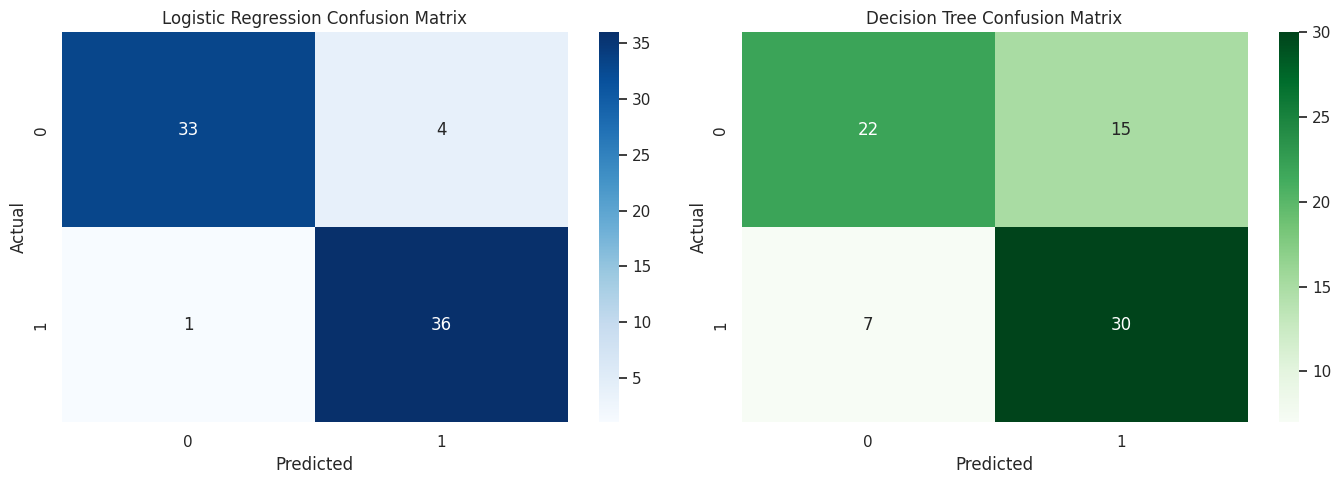

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

7. Conclusion & Next Steps
Based on our project implementation:

Data Preparation: Missing categorical data was successfully handled via mode imputation, and continuous data via median imputation.

Visual Insights: The distribution visualizations indicated right-skewness in both income and loan amounts, which is standard for financial applications.

Model Selection: Both models provide a baseline framework. In credit risk tasks, focusing on minimizing False Negatives (predicting someone won't default when they actually will) is crucial to saving the institution money.